In [144]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sp
from IPython.display import clear_output
import time

In [145]:
class Agent:
    def __init__(self, id, preferences, bundle, initial_wealth, vision, position, metabolic_rate, reproduction_rate):
        self.id = id
        self.preferences = preferences
        self.bundle = bundle
        self.utility = initial_wealth
        self.vision = vision
        self.position = position
        self.metabolic_rate = metabolic_rate
        self.reproduction_rate = reproduction_rate
        self.MRS = {}
    
    def utility_function(self, resources):
        #util = resources**self.preferences[0]
        total_preferences = sum(self.preferences)
        resources_utility = []
        for id, resource in enumerate([resources]):
            
            pref = self.preferences[id]/total_preferences

            resource_preference = resource**pref
            resources_utility.append(resource_preference)
        utility = math.prod(resources_utility)
        return utility

        
    def calc_MRS(self, good_i, good_j):

        weight_good_i = self.preferences[good_i]
        weight_good_j = self.preferences[good_j]

        quantity_good_i = self.bundle[good_i]
        quantity_good_j = self.bundle[good_j]

        #amount of good j needed to = value of one unit of good i
        MRS = (quantity_good_j/weight_good_j)/(quantity_good_i/weight_good_i)
        return MRS
        
    def reproduce(self, other_agent, agents):
        id = len(agents)
        preferences = []
        for preference in range(len(preferences)):
            parent_i_pref = self.preferences[preference]
            parent_j_pref = other_agent.preferences[preference]
            preference[preference] = (parent_i_pref+parent_j_pref)/2

        offspring = Agent(id)
        agents.append()

    def move(self, environment, agents):
        next_position = self.position
        next_utility = self.utility_function(environment.get_resource_at(next_position))
        for dx in range(-self.vision, self.vision + 1):
            for dy in range(-self.vision, self.vision + 1):
                potential_position = (self.position[0] + dx, self.position[1] + dy)
                if environment.is_valid_position(potential_position):
                    potential_utility = self.utility_function(environment.get_resource_at(potential_position))
                    agent_collision = 0
                    for a in agents:
                        if potential_position == a.position:
                            agent_collision += 1
                    if  agent_collision == 0:
                        if potential_utility> next_utility:
                            next_position = potential_position
                            next_utility = potential_utility
        self.position = next_position
        self.utility += next_utility


    def metabolism(self, agents):
        if self.utility - self.metabolic_rate <=0:
            agents.remove(self)
            return 1
        else:
            self.utility -= self.metabolic_rate
            return 0



In [146]:

#Generate the landscape based on 
def generate_landscape(height, width, resource_fn, max_resource=10):
    y, x = np.meshgrid(np.linspace(0, 1, height), np.linspace(0, 1, width), indexing='ij')
    z = np.clip(resource_fn(x, y), 0, None)
    return z / z.max() * max_resource if z.max() > 0 else z

class Environment:
    def __init__(self, height, width, resource_fn, max_resource=10):

        #generate landscape with these attributes
        self.max_landscape = generate_landscape(height, width, resource_fn, max_resource)

        self.landscape = self.max_landscape.copy()

    #Check if position is on the board
    def is_valid_position(self, position):
        x, y = position
        return 0 <= x < self.landscape.shape[0] and 0 <= y < self.landscape.shape[1]

    #Get resource value at a position
    def get_resource_at(self, position):
        return self.landscape[position]

    #set_resource value (used in depletion and regrowth)
    def set_resource_at(self, position, value):
        max_value = self.max_landscape[position]
        self.landscape[position] = np.clip(value, 0, max_value)

    #Used in deplete resource function (currently in update -> will move to be determined by agent choice)
    def deplete_resource_at(self, position, amount=1.0):
        self.set_resource_at(position, self.get_resource_at(position) - amount)

    #Regrow resources used in regrow resource function (in update)
    def regrow_resources(self, growth_rate=0.1):
        # Regrow each cell toward max_landscape.
        deficit = self.max_landscape - self.landscape
        self.landscape += growth_rate * deficit
        self.landscape = np.clip(self.landscape, 0, self.max_landscape)



In [147]:
def get_truncated_normal(mean=0.5, sd=0.1, low=0, high=1):
    # Truncnorm takes bounds in terms of standard deviations from the mean
    a = (low - mean) / sd
    b = (high - mean) / sd
    return sp.stats.truncnorm(a, b, loc=mean, scale=sd).rvs()

In [148]:
def initialize(num_agents, environment_size, landscape_function, max_resource, metabolic_rate, preferences, vision, reproduction_rate):
    env = Environment(environment_size[0], environment_size[1], landscape_function, max_resource)
    # Initialize agents with random positions and parameters
    agents = []
    for agent in range(num_agents):
        # Stochastic Params
        position = (np.random.randint(0, env.landscape.shape[0]), np.random.randint(0, env.landscape.shape[1]))
        initial_wealth = 0  # Initial wealth for each agent
        initial_bundle = None #placeholder for when I add multiple good types
        preference_for_good_1 = get_truncated_normal(preferences, sd=.1, low = 0, high = 1)
        agent_preferences =  [preference_for_good_1, 1-preference_for_good_1]
        
        agents.append(Agent(agent, agent_preferences, initial_bundle, initial_wealth, vision, position, metabolic_rate, reproduction_rate))
    return agents, env

In [149]:
def deplete_resources(agents, env, depletion_amount=1.0):
    #deplete resources as agents use them (right now just where agents are, but will move to be determined by agents action choice)
    for agent in agents:
        env.deplete_resource_at(agent.position, amount=depletion_amount)


def regrow_resources(env, growth_rate=0.1):
    #regrow towards max_value based on growth rate
    env.regrow_resources(growth_rate=growth_rate)


def update(agents, env, resource_depletion_rate, resource_regrowth_rate):

    dead_agents = 0
    #update each agents
    for a in agents:

        #move
        a.move(env, agents)

        #metabolism (and death)
        dead_agents += a.metabolism(agents)


    deplete_resources(agents, env, resource_depletion_rate)

    regrow_resources(env, resource_regrowth_rate)

    return dead_agents



In [150]:
def observe(agents, env, death):
    #Plot landscape
    plt.imshow(env.landscape, cmap='viridis')
    plt.colorbar(label='Resource Level')

    #Plot agents
    utilities = [agent.utility for agent in agents]
    scatter = plt.scatter(
        [agent.position[1] for agent in agents],
        [agent.position[0] for agent in agents],
        c=utilities,
        cmap='plasma',
        edgecolors='black',
        label='Agents'
    )

    plt.colorbar(scatter, label='Agent Utility')
    plt.title('Environment Landscape')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

    #Plot amount of agents who die each time step
    plt.plot(death, label='Death Rate')
    plt.title('# of Agents Who Die Each Time-Step')
    plt.xlabel('Time-Step')
    plt.ylabel('Death Count')
    plt.show()

    #Plot utility distribution
    plt.hist(utilities, label = 'Utility Distribution')
    plt.title('Utility Distribution')
    plt.xlabel('Utility')
    plt.ylabel('Count')
    plt.show()

    #Plot average utility & quartiles




In [151]:
def run(time_steps, num_agents, environment_size, landscape_function, max_resource, resource_depletion_rate, resource_regrowth_rate, metabolic_rate, preferences, vision, reproduction_rate):
    agents, env = initialize(num_agents, environment_size, landscape_function, max_resource, metabolic_rate, preferences, vision, reproduction_rate)
    death = []
    for t in range(time_steps):

        dead_agents = update(agents, env, resource_depletion_rate, resource_regrowth_rate)

        death.append(dead_agents)

        observe(agents, env, death)

        clear_output(wait=True)

        time.sleep(.01)



    observe(agents, env, death)



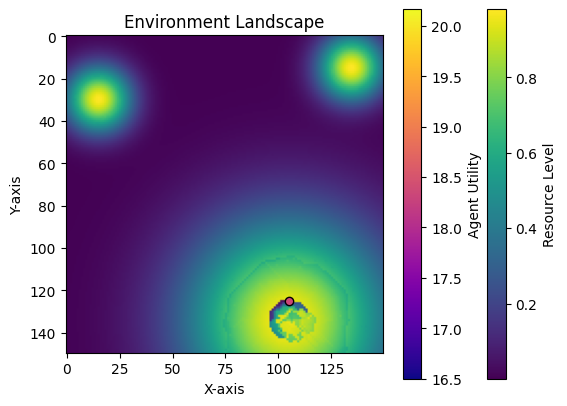

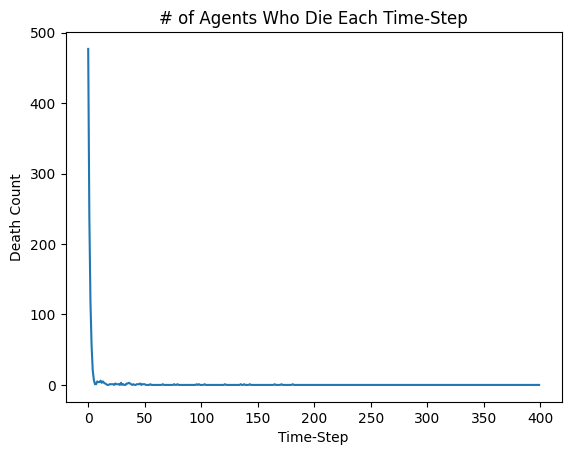

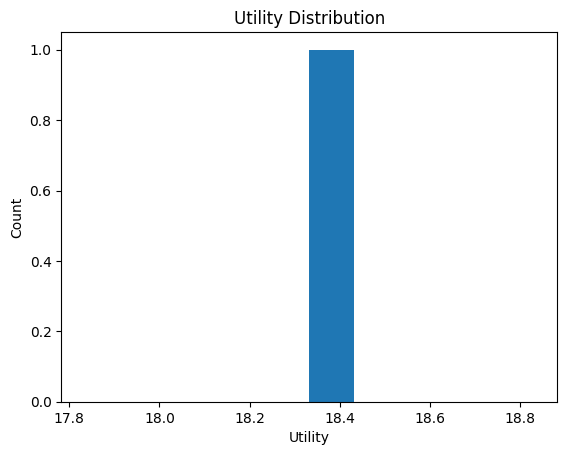

In [152]:
f = lambda x, y: np.exp(-((x - 0.9) ** 2 + (y - 0.1) ** 2)/.01)+ np.exp(-((x - 0.1) ** 2 + (y - 0.2) ** 2)/.01) + np.exp(-((x - 0.7) ** 2 + (y - 0.9) ** 2)/.1) #Function that determines the landscape

run(time_steps=400, num_agents=1000, environment_size=(150, 150), landscape_function=f, max_resource=1, resource_depletion_rate=1, resource_regrowth_rate=.01, metabolic_rate=.9, preferences=.5, vision = 1, reproduction_rate = .1)